Instalimi dhe importimi i librarive të nevojshme

In [ ]:
pip install pandas scipy seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.0/7.8 MB 217.9 kB/s eta 0:00:36
     ---------------------------------------- 0.1/7.8 MB 122.9 kB/s eta 0:01:04
  

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import warnings
from scipy.stats import zscore
import seaborn as sns
import matplotlib.pyplot as plt

warnings.simplefilter(action='ignore', category=FutureWarning)

Mbledhja e të dhënave, definimi i tipeve të dhënave, kualiteti i të dhënave

In [16]:
df = pd.read_csv(r'./master.csv')

print(df.dtypes)
print(df.describe())

country                object
year                    int64
sex                    object
age                    object
suicides_no             int64
population              int64
suicides/100k pop     float64
country-year           object
HDI for year          float64
 gdp_for_year ($)      object
gdp_per_capita ($)      int64
generation             object
dtype: object
               year   suicides_no    population  suicides/100k pop  \
count  27820.000000  27820.000000  2.782000e+04       27820.000000   
mean    2001.258375    242.574407  1.844794e+06          12.816097   
std        8.469055    902.047917  3.911779e+06          18.961511   
min     1985.000000      0.000000  2.780000e+02           0.000000   
25%     1995.000000      3.000000  9.749850e+04           0.920000   
50%     2002.000000     25.000000  4.301500e+05           5.990000   
75%     2008.000000    131.000000  1.486143e+06          16.620000   
max     2016.000000  22338.000000  4.380521e+07         224.970000

Riemërimi i kolonave për përdorim më të lehtë

In [17]:
df=df.rename(columns={'sex':'gender','gdp_per_capita ($)':'gdp_per_capita',' gdp_for_year ($) ':'gdp_for_year', 'HDI for year' : 'hdi_for_year'})

Modifikimi i tipit të dhënave për kolonën 'gdp_for_year'

In [18]:
df['gdp_for_year'] = df['gdp_for_year'].str.replace(',', '').astype(int)

Ndryshimi i dimensionalitetit

In [19]:
df = df[['country','year', 'gender', 'age', 'suicides_no','population','suicides/100k pop','gdp_for_year','gdp_per_capita','hdi_for_year']]

Menaxhimi i vlerave null

In [20]:
df = df.sort_values(by=['country', 'year'])

df['hdi_for_year'] = df.groupby('country')['hdi_for_year'].transform(lambda x: x.fillna(method='ffill').fillna(method='bfill'))

yearly_mean = df.groupby(['country', 'year'])['hdi_for_year'].mean().reset_index()

yearly_mean['hdi_for_year'] = yearly_mean.groupby('country')['hdi_for_year'].transform(lambda x: x.interpolate(method='linear'))

df = df.merge(yearly_mean, on=['country', 'year'], suffixes=('', '_mean'))

df['hdi_for_year'] = df['hdi_for_year'].combine_first(df['hdi_for_year_mean'])

df = df.drop(columns=['hdi_for_year_mean'])

Mostrimi i të dhënave (10%)

In [21]:
sampled_data = df.sample(frac=0.1)
print(sampled_data)

              country  year  gender          age  suicides_no  population  \
11644         Hungary  2014  female    75+ years           81      508688   
7277   Czech Republic  2005    male  35-54 years          516     1427262   
16678          Mexico  1994  female    75+ years           12      764600   
10956       Guatemala  2007    male  35-54 years           74      956182   
15505      Luxembourg  2001    male  15-24 years            3       25762   
...               ...   ...     ...          ...          ...         ...   
13724           Japan  2015    male    75+ years         2297     6289365   
12122         Ireland  1990  female  55-74 years           20      269100   
13608           Japan  2005  female    75+ years         1600     7307828   
4769         Bulgaria  2003  female  15-24 years           13      527203   
16886          Mexico  2011  female   5-14 years          107    11496698   

       suicides/100k pop   gdp_for_year  gdp_per_capita  hdi_for_year  
116

Validimi i vlerave duplikate <br>
Kontrollimi i kolonave specifike

In [22]:
duplicates_check=['country','year','gender','age']
duplicates=df.duplicated(subset=duplicates_check)

if duplicates.any():
    print("Duplicates found. Dropping duplicates.")
    df = df.drop_duplicates()
    print("\nCleaned DataFrame:")
    print(df)
else:
    print("No duplicates found. DataFrame remains unchanged.")

No duplicates found. DataFrame remains unchanged.


Kontrollimi i tërë dataframe-it


In [23]:
duplicates = df.duplicated()

if duplicates.any():
    print("Duplicates found.")
else:
    print("No duplicates found.")

No duplicates found.


Transformimi i kolonave specifike

In [24]:
df['total_suicides'] = df.groupby('year')['suicides_no'].transform('sum')

df['suicides_to_population_ratio'] = df['suicides_no'] / df['population']

Diskretizimi i perpjestimit të vetëvrasjeve me numrin e popullesisë dhe i gdp në kategori më të përshtatshme

In [25]:
ratio_bins = [-1, 0, 1e-05, 2e-05, 4e-05, 6e-05, 8e-05, 1e-04]  
ratio_labels = ['None','Very Low', 'Low', 'Medium', 'High', 'Very High', 'Extreme']

df['suicides_to_population_ratio_discretize'] = pd.cut(df['suicides_to_population_ratio'], bins=ratio_bins, labels=ratio_labels)

gdp_bins = [0, 1000, 2000, 3000]
gdp_labels = ['Low', 'Medium', 'High']
df['gdp_category'] = pd.cut(df['gdp_per_capita'], bins=gdp_bins, labels=gdp_labels)

Binarizimi i kolones 'gender'

In [26]:
df['gender_encoded'] = df['gender'].map({'male': 1, 'female': 0})

Ruajtja e transformimeve ne nje file te ri

In [27]:
df.to_csv('cleaned_data.csv', index=False)

Outlires Detection

Z-Score Method 

In [5]:
df=pd.read_csv(r'./cleaned_data.csv')

numerical_columns = [
    "suicides_no", "population", "suicides/100k pop",
    "gdp_for_year", "gdp_per_capita", "hdi_for_year",
    "total_suicides", "suicides_to_population_ratio"
]

z_scores = df[numerical_columns].apply(zscore)  # Calculate z-scores
outliers = (z_scores.abs() > 3)  # Identify outliers
df_outliers = df[outliers.any(axis=1)]  # Filter rows with outliers

Interquartile Range (IQR)

In [ ]:
# Q1 = df[numerical_columns].quantile(0.25)
# Q3 = df[numerical_columns].quantile(0.75)
# IQR = Q3 - Q1

# # Define outliers
# outliers = ((df[numerical_columns] < (Q1 - 1.5 * IQR)) |
#             (df[numerical_columns] > (Q3 + 1.5 * IQR)))

# df_outliers = df[outliers.any(axis=1)]

Display Outliers

In [8]:
print(df_outliers.shape[0])  # Number of outlier rows
outlier_columns = outliers.any(axis=0)  # Check columns with outliers
print(outlier_columns[outlier_columns].index.tolist())  # List of columns with outliers

2394
['suicides_no', 'population', 'suicides/100k pop', 'gdp_for_year', 'gdp_per_capita', 'total_suicides', 'suicides_to_population_ratio']


Use visualization to inspect outliers

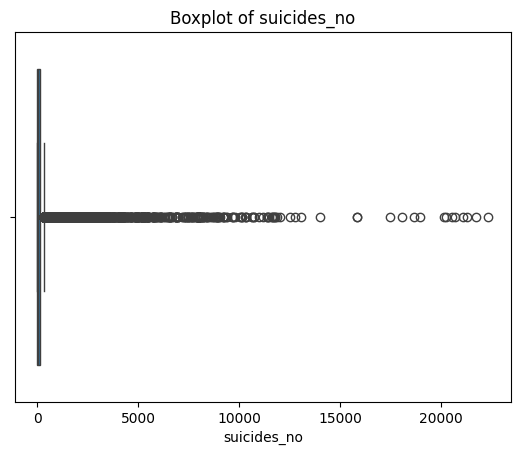

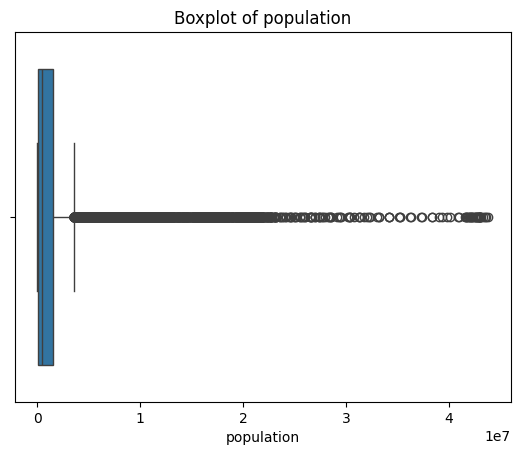

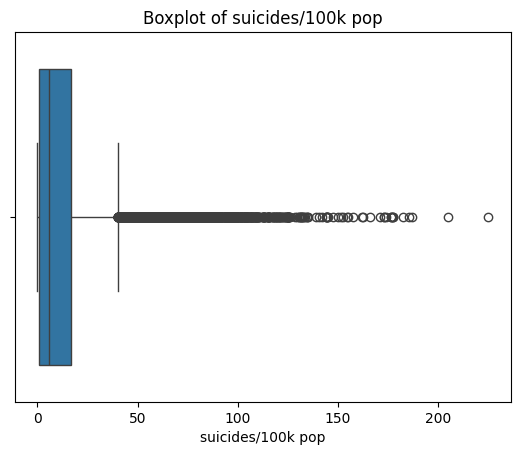

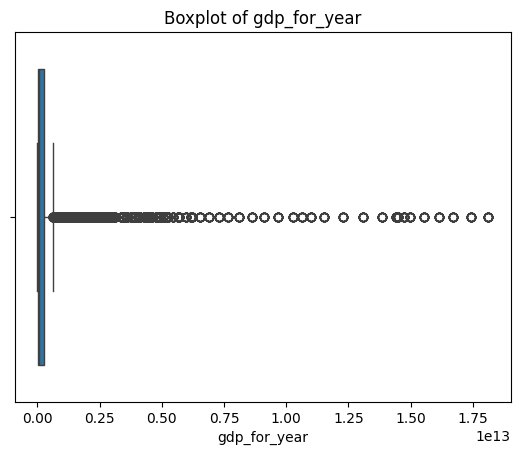

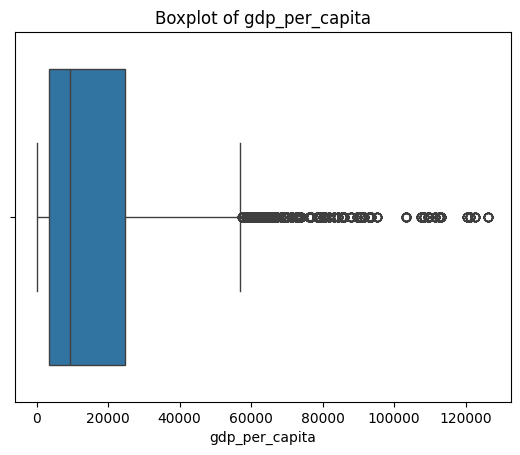

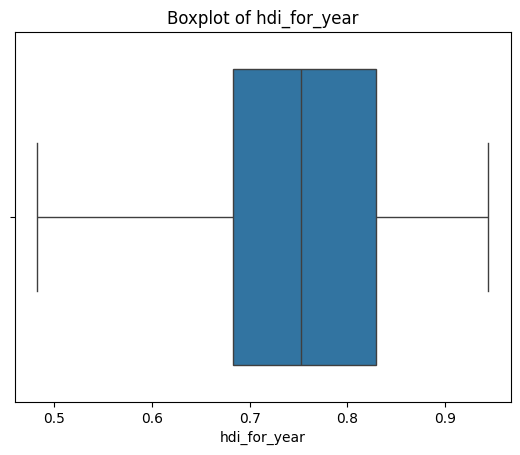

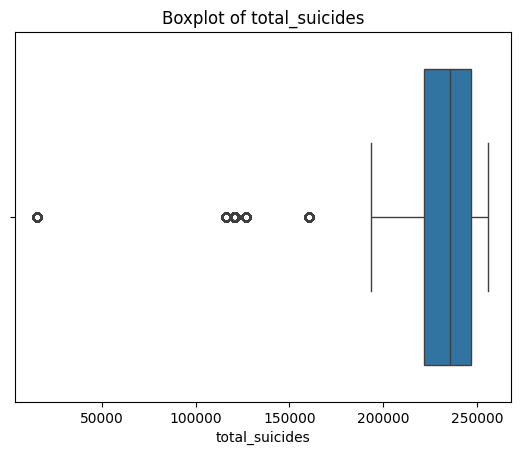

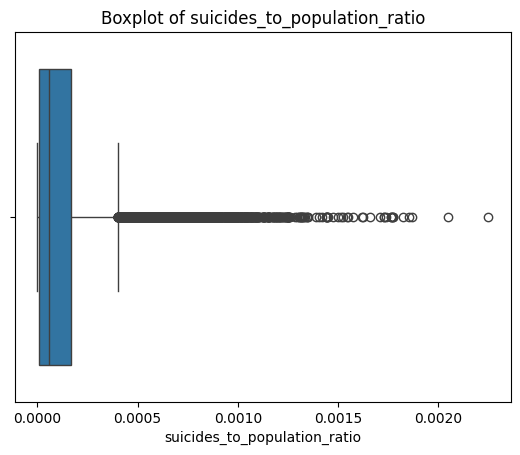

In [12]:
for column in numerical_columns:
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

Scatterplot to identify outliers in relationships

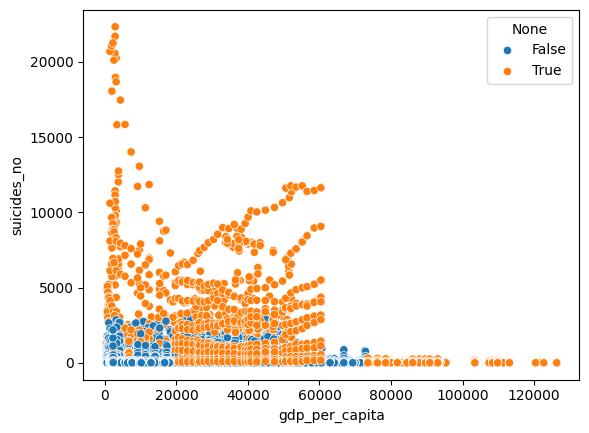

In [13]:
sns.scatterplot(data=df, x="gdp_per_capita", y="suicides_no", hue=outliers.any(axis=1))
plt.show()

Frequency Analysis

In [15]:
categorical_columns = ["country", "year", "gender", "gdp_category"]
for col in categorical_columns:
    print(df[col].value_counts())

country
Austria                   382
Mauritius                 382
Netherlands               382
Iceland                   382
Brazil                    372
                         ... 
Bosnia and Herzegovina     24
Dominica                   12
Cabo Verde                 12
Macau                      12
Mongolia                   10
Name: count, Length: 101, dtype: int64
year
2009    1068
2001    1056
2010    1056
2003    1032
2011    1032
2007    1032
2000    1032
2002    1032
2006    1020
2008    1020
2004    1008
2005    1008
1999     996
2012     972
2013     960
1998     948
1995     936
2014     936
1997     924
1996     924
1994     816
1992     780
1993     780
1990     768
1991     768
2015     744
1987     648
1989     624
1988     588
1985     576
1986     576
2016     160
Name: count, dtype: int64
gender
male      13910
female    13910
Name: count, dtype: int64
gdp_category
Medium    2412
High      2076
Low       1608
Name: count, dtype: int64
